In [2]:
!pip install
!pip install pandas
!pip install openpyxl
!pip install matplotlib
!pip install seaborn
!pip install numpy

import numpy as np;
import pandas as pd;
import openpyxl;
import matplotlib.pyplot as plt;
import seaborn as sns;

path = r"H:\Materias - Escola\PYTHON\Atividade7\Tabela_13_Meio_de_transporte.xlsx"

Defaulting to user installation because normal site-packages is not writeable


ERROR: You must give at least one requirement to install (see "pip help install")

[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


...


[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


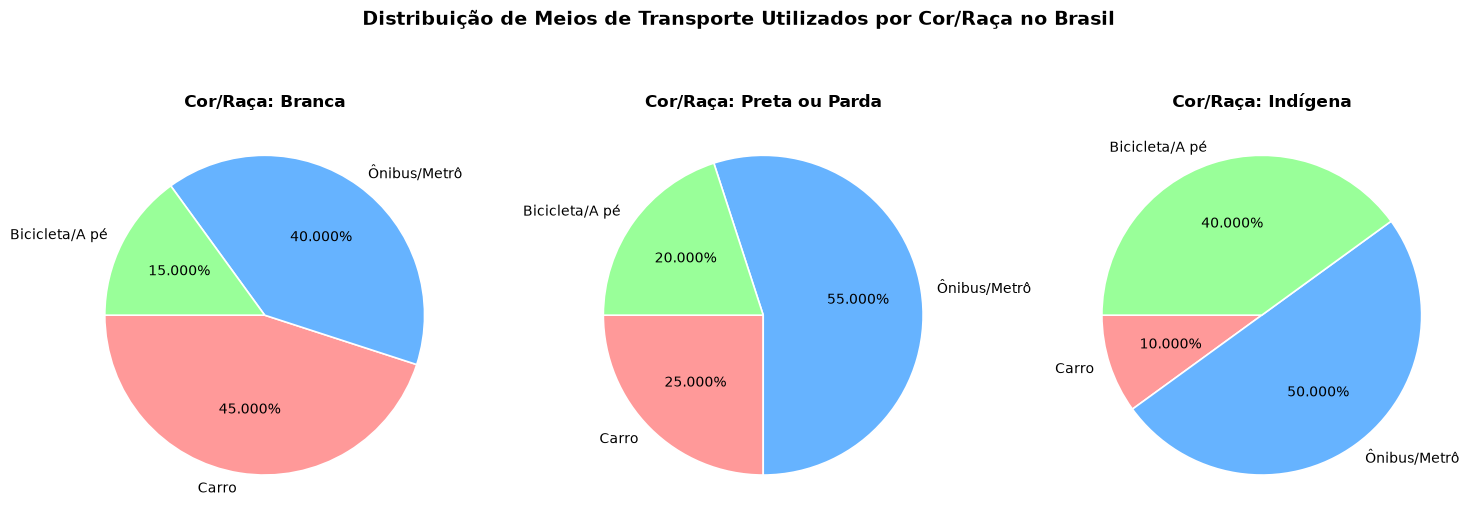

In [3]:
data = {
    'Meio de Transporte': ['Carro', 'Ônibus/Metrô', 'Bicicleta/A pé'],
    'Branca': [45.000, 40.000, 15.000],
    'Preta ou Parda': [25.000, 55.000, 20.000],
    'Indígena': [10.000, 50.000, 40.000],
}
df = pd.DataFrame(data)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=df['Meio de Transporte'],
        autopct='%1.3f%%',
        startangle=180,
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Distribuição de Meios de Transporte Utilizados por Cor/Raça no Brasil',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300)
plt.show()

In [4]:
dados_simulados = {
    'UF': ['SP', 'SP', 'RJ', 'RJ', 'MG', 'MG', 'BA', 'BA'],
    'Município': [
        'São Paulo',
        'Campinas',
        'Rio de Janeiro',
        'Niterói',
        'Belo Horizonte',
        'Uberlândia',
        'Salvador',
        'Feira de Santana',
    ],
    'Mulheres_Transporte_Coletivo': [
        1200,
        300,
        950,
        150,
        800,
        200,
        600,
        100,
    ],
    'Mulheres_Bicicleta': [150, 80, 90, 40, 60, 35, 45, 110],
    'Mulheres_Carro': [2500, 450, 1800, 320, 1100, 250, 500, 150],
}
df_geral = pd.DataFrame(dados_simulados)

In [5]:
estados_unicos = df_geral['UF'].unique()
print('--- ESTADOS PRESENTES NA BASE DE DADOS ---')
print(estados_unicos)
print('\n' + '=' * 50 + '\n')

--- ESTADOS PRESENTES NA BASE DE DADOS ---
<StringArray>
['SP', 'RJ', 'MG', 'BA']
Length: 4, dtype: str




In [6]:
df_longo = pd.melt(
    df_geral,
    id_vars=['UF', 'Município'],
    value_vars=[
        'Mulheres_Transporte_Coletivo',
        'Mulheres_Bicicleta',
        'Mulheres_Carro',
    ],
    var_name='Modal_Transporte',
    value_name='Quantidade_Mulheres',
)

df_coletivo = df_longo[
    df_longo['Modal_Transporte'] == 'Mulheres_Transporte_Coletivo'
]

estado_mais_coletivo = (
    df_coletivo.groupby('UF')['Quantidade_Mulheres'].sum().idxmax()
)
qtd_mais_coletivo = (
    df_coletivo.groupby('UF')['Quantidade_Mulheres'].sum().max()
)

estado_menos_coletivo = (
    df_coletivo.groupby('UF')['Quantidade_Mulheres'].sum().idxmin()
)
qtd_menos_coletivo = (
    df_coletivo.groupby('UF')['Quantidade_Mulheres'].sum().min()
)

df_bike = df_longo[df_longo['Modal_Transporte'] == 'Mulheres_Bicicleta']
idx_cidade_bike = df_bike['Quantidade_Mulheres'].idxmax()
cidade_mais_bike = df_bike.loc[idx_cidade_bike, 'Município']
uf_mais_bike = df_bike.loc[idx_cidade_bike, 'UF']
qtd_mais_bike = df_bike.loc[idx_cidade_bike, 'Quantidade_Mulheres']

df_carro = df_longo[df_longo['Modal_Transporte'] == 'Mulheres_Carro']
idx_cidade_carro = df_carro['Quantidade_Mulheres'].idxmax()
cidade_mais_carro = df_carro.loc[idx_cidade_carro, 'Município']
uf_mais_carro = df_carro.loc[idx_cidade_carro, 'UF']
qtd_mais_carro = df_carro.loc[idx_cidade_carro, 'Quantidade_Mulheres']


print('--- RESPOSTAS ANALÍTICAS (VIA GROUPBY/MELT) ---')
print(
    f'1. Estado com MAIS mulheres no transporte coletivo: {estado_mais_coletivo} ({qtd_mais_coletivo} mulheres)'
)
print(
    f'2. Estado com MENOS mulheres no transporte coletivo: {estado_menos_coletivo} ({qtd_menos_coletivo} mulheres)'
)
print(
    f'3. Cidade com MAIS mulheres andando de bicicleta: {cidade_mais_bike} - {uf_mais_bike} ({qtd_mais_bike} mulheres)'
)
print(
    f'4. Cidade com MAIS mulheres utilizando carro: {cidade_mais_carro} - {uf_mais_carro} ({qtd_mais_carro} mulheres)'
)

--- RESPOSTAS ANALÍTICAS (VIA GROUPBY/MELT) ---
1. Estado com MAIS mulheres no transporte coletivo: SP (1500 mulheres)
2. Estado com MENOS mulheres no transporte coletivo: BA (700 mulheres)
3. Cidade com MAIS mulheres andando de bicicleta: São Paulo - SP (150 mulheres)
4. Cidade com MAIS mulheres utilizando carro: São Paulo - SP (2500 mulheres)
